In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emirhanai/human-action-detection-artificial-intelligence")

print("Path to dataset files:", path)

100%|██████████| 147M/147M [00:08<00:00, 18.0MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/emirhanai/human-action-detection-artificial-intelligence/versions/1


In [2]:
!cp -r /root/.cache/kagglehub/datasets/emirhanai/human-action-detection-artificial-intelligence/versions/1 /content/data

In [3]:
from torchvision.transforms import v2
import torch

transform_train = v2.Compose([
    v2.Resize((224 ,224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = v2.Compose([
    v2.Resize((224 ,224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [4]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

batch_size = 32
train_dir = "/content/data/emirhan_human_dataset/datasets/human_data/train_data"
test_dir = "/content/data/emirhan_human_dataset/datasets/human_data/test_data"

train_dataset = ImageFolder(root=train_dir, transform=transform_train, target_transform=None)
test_dataset = ImageFolder(root=test_dir, transform=transform_test, target_transform=None)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
from torchvision import models

model = models.resnet18(weights="IMAGENET1K_V1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
!pip install torchinfo

In [7]:
from torchinfo import summary

summary(model, input_size=(batch_size, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│

In [8]:
len(train_dataset.classes)

15

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

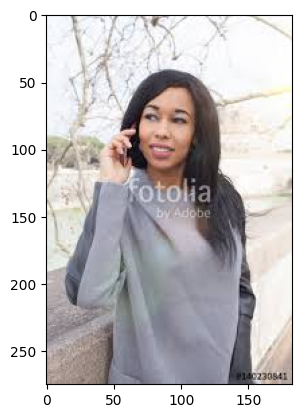

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open(train_dataset.imgs[1][0])
img = np.array(img)
plt.imshow(img)
plt


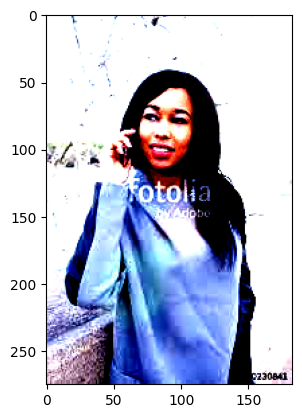

In [10]:
img = transform_train(img)
img = img.permute(1, 2, 0)
img = img.numpy()
plt.imshow(img)

In [11]:
from torch import nn

num_classes = len(train_dataset.classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)


In [13]:
img = Image.open("/content/data/emirhan_human_dataset/datasets/human_data/train_data/calling/images_083.jpg")
img = transform_train(img)
img = img.to(device)

model.eval()
with torch.inference_mode():
  y_preds = model(img.unsqueeze(dim=0))
  y_preds = torch.softmax(y_preds, dim=1)
  y_preds = torch.argmax(y_preds, dim=1)

print(y_preds)

tensor([9], device='cuda:0')


In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

In [15]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [16]:
def train_model(model, train_loader, loss_fn, optimizer):
  model.train()
  running_loss = 0
  acc = 0

  for batch, (X,y) in enumerate(train_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    running_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc += accuracy_fn(y, y_pred.argmax(dim=1))

  acc /= len(train_loader)
  running_loss /= len(train_loader)
  return running_loss, acc

In [17]:
def test_model(model, loss_fn, test_loader, scheduler):
  model.eval()
  test_loss = 0
  test_acc = 0

  with torch.inference_mode():
    for batch, (X,y) in enumerate(test_loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      test_loss += loss.item()
      test_acc += accuracy_fn(y_pred=y_pred.argmax(dim=1), y_true=y)

    test_acc /= len(test_loader)
    test_loss /= len(test_loader)
    scheduler.step(test_loss)

  return test_loss, test_acc

In [18]:
import time

epochs = 10
start = time.time()
for epoch in range(epochs):
  train_loss, train_acc = train_model(model=model, loss_fn=loss_fn, optimizer=optimizer, train_loader=train_loader)
  test_loss, test_acc = test_model(model=model, loss_fn=loss_fn, test_loader=test_loader, scheduler=scheduler)
  print(f"Epoch: {epoch} | Train loss: {train_loss} | Train acc {train_acc} | Test loss {test_loss} | Test acc {test_acc}")
end = time.time()
print(f"Time taken: {end-start}")

Epoch: 0 | Train loss: 1.0814527688123017 | Train acc 66.45122601279317 | Test loss 0.8765190492998413 | Test acc 71.91932624113475
Epoch: 1 | Train loss: 0.558657492338213 | Train acc 82.77585287846482 | Test loss 0.8020901710112044 | Test acc 74.88918439716312
Epoch: 2 | Train loss: 0.338612058309159 | Train acc 89.8343105899076 | Test loss 0.8094132444325913 | Test acc 74.40159574468085
Epoch: 3 | Train loss: 0.19722280042893342 | Train acc 94.70060412224592 | Test loss 0.8512439772367795 | Test acc 75.22163120567376
Epoch: 4 | Train loss: 0.1292541430496585 | Train acc 96.59514925373135 | Test loss 0.8448363769789563 | Test acc 75.41001773049646
Epoch: 5 | Train loss: 0.06525869937990901 | Train acc 98.52745202558636 | Test loss 0.7485324398198343 | Test acc 78.29122340425532
Epoch: 6 | Train loss: 0.047023334841269734 | Train acc 99.06716417910448 | Test loss 0.7534746840160261 | Test acc 78.36879432624114
Epoch: 7 | Train loss: 0.034054418382391746 | Train acc 99.52025586353945 |

In [20]:
img = Image.open("/content/data/emirhan_human_dataset/datasets/human_data/test_data/drinking/images_063 (4).jpg")

model.eval()
img = transform_test(img)
img = img.to(device)

with torch.inference_mode():
  y_preds = model(img.unsqueeze(dim=0))
  y_preds = torch.softmax(y_preds, dim=1)
  y_preds = torch.argmax(y_preds, dim=1)

y_preds.item()
class_names = train_dataset.classes
class_names[y_preds.item()]

'drinking'

In [21]:
%%capture
!pip install torchmetrics

In [24]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import numpy as np

def make_confusion_matrix(model, test_loader):
  model.eval()
  y_true = []
  y_pred= []

  with torch.inference_mode():
    for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      #_, predicted = torch.max(outputs, 1)
      test_preds = torch.softmax(outputs.squeeze(), dim=1).argmax(dim=1)
      y_true.append(labels.cpu().numpy())
      y_pred.append(test_preds.cpu().numpy())

  y_pred = np.concatenate(y_pred)
  y_pred = torch.tensor(y_pred)

  test_dataset.targets = torch.tensor(test_dataset.targets)

  confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
  confmat_tensor = confmat(preds = y_pred, target=test_dataset.targets)

  fig, ax = plot_confusion_matrix(
      conf_mat = confmat_tensor.numpy(),
      class_names = class_names,
      figsize=(10,10)

  )

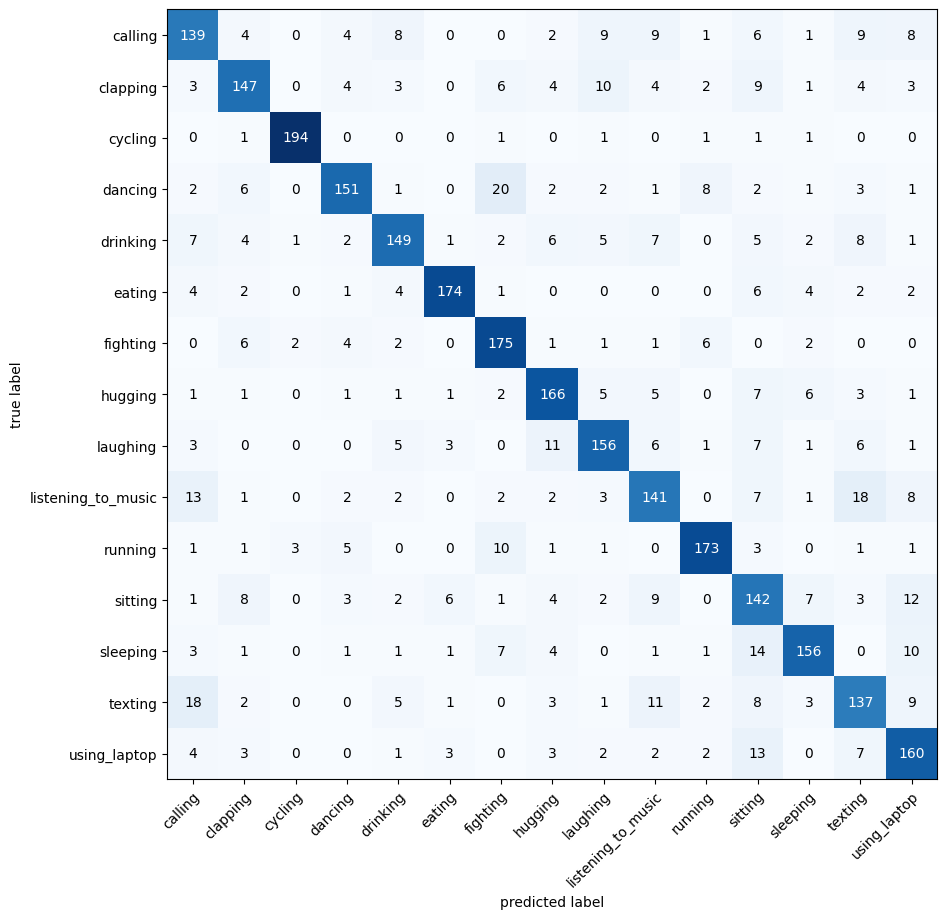

In [25]:
make_confusion_matrix(model, test_loader)

In [26]:
from torchvision import models
model_2 = models.resnet18(weights="IMAGENET1K_V1")

for param in model_2.parameters():
  param.requires_grad = False

num_ftrs  = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

model_2.to(device)

optimizer = torch.optim.Adam(model_2.fc.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

In [27]:
import time

epochs = 10
start= time.time()
for epoch in range(10):
  train_loss, train_acc = train_model(model=model_2, loss_fn=loss_fn, optimizer=optimizer, train_loader=train_loader)
  test_loss, test_acc = test_model(model=model_2, loss_fn=loss_fn, test_loader=test_loader, scheduler=scheduler)
  print(f"Epoch: {epoch} | Train loss: {train_loss} | Train acc: {train_acc} | test loss: {test_loss} | test acc: {test_acc}")

end = time.time()
print(f"Time taken : {end-start}")

Epoch: 0 | Train loss: 2.338391963098603 | Train acc: 29.539800995024873 | test loss: 2.025164956742145 | test acc: 44.182180851063826
Epoch: 1 | Train loss: 1.817518774888663 | Train acc: 50.65742714996446 | test loss: 1.7216562451200281 | test acc: 51.628989361702125
Epoch: 2 | Train loss: 1.5756985157537562 | Train acc: 55.808013503909024 | test loss: 1.566656342529236 | test acc: 53.756648936170215
Epoch: 3 | Train loss: 1.449847954676858 | Train acc: 57.88024164889836 | test loss: 1.4747936941207724 | test acc: 55.25265957446808
Epoch: 4 | Train loss: 1.3676501703160657 | Train acc: 59.80143923240938 | test loss: 1.4134514420590503 | test acc: 56.6156914893617
Epoch: 5 | Train loss: 1.3105173035979525 | Train acc: 60.69873845060412 | test loss: 1.3710764156694109 | test acc: 57.546542553191486
Epoch: 6 | Train loss: 1.2653734441250881 | Train acc: 61.631574271499645 | test loss: 1.3300581279587238 | test acc: 58.53280141843971
Epoch: 7 | Train loss: 1.2295668995710833 | Train acc:

/tmp/ipykernel_1831/293379540.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset.targets = torch.tensor(test_dataset.targets)


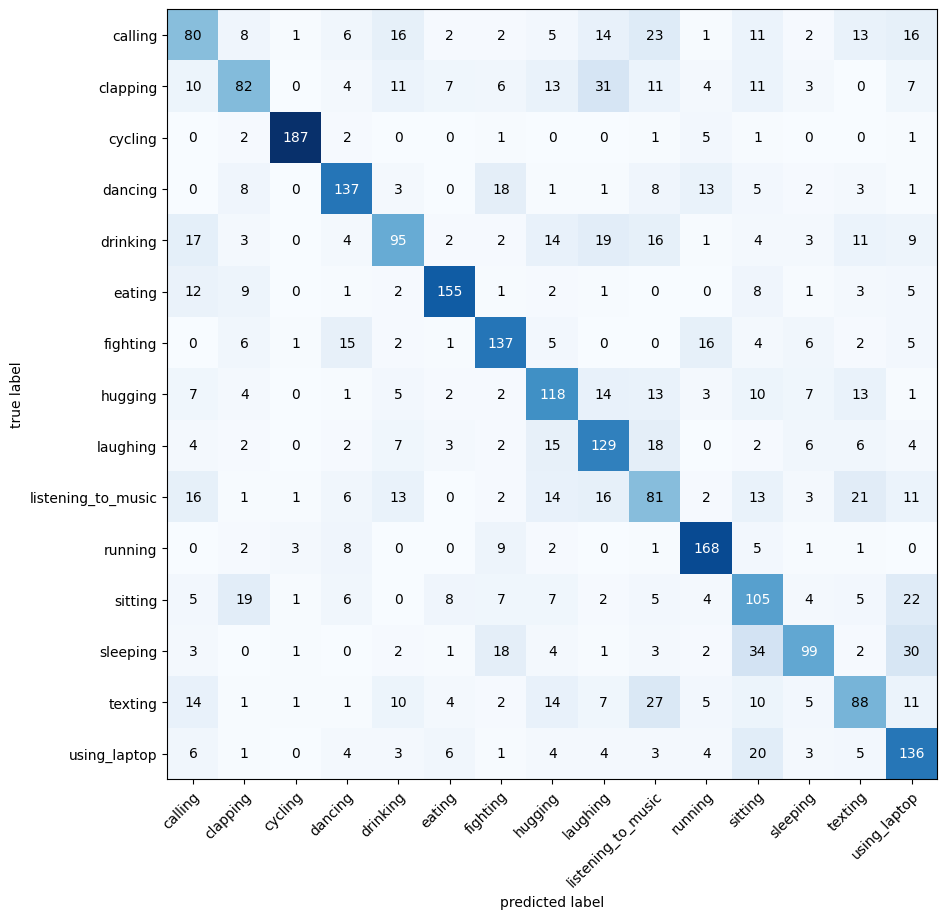

In [28]:
make_confusion_matrix(model=model_2, test_loader=test_loader)